In [1]:
!pip install mlflow


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:


import mlflow

mlflow.set_tracking_uri("file:./mlruns")

with mlflow.start_run():
    mlflow.log_param("param1", 15)
    mlflow.log_metric("metric1", 0.89)

In [3]:
import numpy as np
import pandas as pd

In [4]:
import os
df = pd.read_csv('tweets_v8.csv' if os.path.exists('tweets_v8.csv') else '/content/tweets_v8.csv' if os.path.exists('/content/tweets_v8.csv') else 'data/external/tweets_v8.csv' if os.path.exists('data/external/tweets_v8.csv') else '../data/external/tweets_v8.csv')
# Tweets have no ground-truth sentiment labels: 'text' is the raw tweet column.
# Rename to 'clean_comment' so the downstream experiment code stays unchanged.
df = df.rename(columns={'text': 'clean_comment'})
if 'is_retweet' in df.columns:
    df = df[~df['is_retweet'].astype(bool)]  # drop retweets

In [5]:
df.dropna(inplace=True)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df = df[~(df['clean_comment'].str.strip() == '')]

In [8]:
# Pseudo-label tweets with VADER (the dataset has no ground-truth sentiment labels)
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
df['sentiment_polarity'] = df['clean_comment'].apply(lambda t: sia.polarity_scores(str(t))['compound'])
df['category'] = df['sentiment_polarity'].apply(lambda s: 1 if s >= 0.05 else (-1 if s <= -0.05 else 0))
df['category'].value_counts()

category
 1    21536
 0    21323
-1    11177
Name: count, dtype: int64

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [10]:
# Ensure necessary NLTK data is downloaded
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HAI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HAI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
# Define the preprocessing function
def preprocess_comment(comment):
    # Convert to lowercase
    comment = comment.lower()

    # Remove trailing and leading whitespaces
    comment = comment.strip()

    # Remove newline characters
    comment = re.sub(r'\n', ' ', comment)

    # Remove non-alphanumeric characters, except punctuation
    comment = re.sub(r'[^A-Za-z0-9\s!?.,]', '', comment)

    # Remove stopwords but retain important ones for sentiment analysis
    stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
    comment = ' '.join([word for word in comment.split() if word not in stop_words])

    # Lemmatize the words
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment

In [12]:
# Apply the preprocessing function to the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)

In [13]:
df.head()

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category
3,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,"blood 1st slide im joining squidgame thing, im...",Twitter Web App,False,-0.6486,-1
4,Laura Reactions,France,I talk and I make reactions videos about shows...,2018-12-19 20:38:28+00:00,330,152,2278,False,2021-10-06 12:05:00+00:00,"two first games, player killed mask guy bloody...",Twitter Web App,False,-0.9169,-1
5,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,thg going explode 4b marketcap soon. world fir...,Twitter for Android,False,0.0000,0
7,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote daily poll. thanks. think donny va...,Twitter for iPhone,False,0.8708,1
9,Kevin Franco,"Calgary, Canada",When it comes to describing myself in a one li...,2009-05-11 20:14:51+00:00,1027,278,20902,False,2021-10-06 12:04:10+00:00,discovered english audio 5 episode squid game ...,Twitter Web App,False,0.0000,0


In [14]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Step 1: Vectorize the comments using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=10000)  # Bag of Words model with a limit of 1000 features

In [16]:
X = vectorizer.fit_transform(df['clean_comment'])
y = df['category']  # Assuming 'sentiment' is the target variable (0 or 1 for binary classification)

In [17]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 454232 stored elements and shape (54036, 10000)>

In [18]:
X.shape

(54036, 10000)

In [19]:
y

3       -1
4       -1
5        0
7        1
9        0
        ..
80007    0
80009    0
80013    0
80014    1
80017    1
Name: category, Length: 54036, dtype: int64

In [20]:
y.shape

(54036,)

In [21]:
# Step 2: Set up the MLflow tracking server
mlflow.set_tracking_uri("file:./mlruns")

In [22]:
# Set or create an experiment
mlflow.set_experiment("RF Baseline")

2026/08/24 19:54:11 INFO mlflow.tracking.fluent: Experiment with name 'RF Baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///C:/Users/HAI/Downloads/Youtube sentiment '
 'analysis/notebooks/mlruns/678878503071230967'), creation_time=1787581451681, experiment_id='678878503071230967', last_update_time=1787581451681, lifecycle_stage='active', name='RF Baseline', tags={}>

2026/08/24 19:54:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 0.6741302738712065


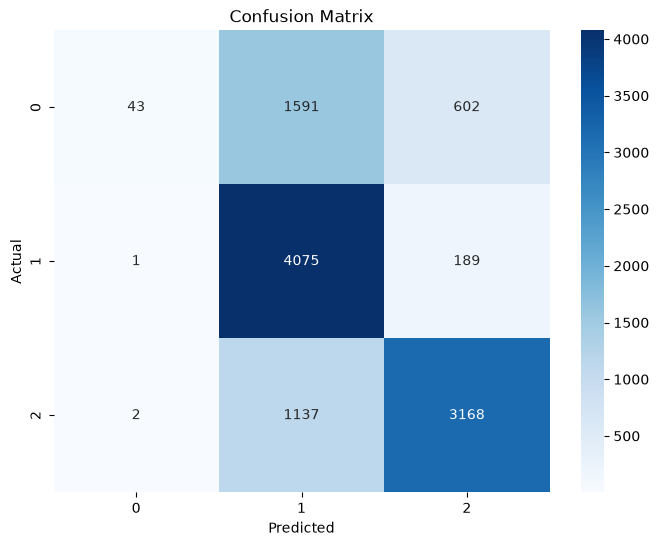

In [23]:
# Step 1: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Define and train a Random Forest baseline model using a simple train-test split
with mlflow.start_run() as run:
    # Log a description for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    # Add a description
    mlflow.set_tag("description", "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with a simple train-test split")

    # Log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    # Log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Save and log the confusion matrix plot
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    # Log the Random Forest model
    mlflow.sklearn.log_model(model, "random_forest_model")

    # Optionally log the dataset itself (if it's small enough)
    df.to_csv("dataset.csv", index=False)
    mlflow.log_artifact("dataset.csv")

# Display final accuracy
print(f"Accuracy: {accuracy}")

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.93      0.02      0.04      2236
           0       0.60      0.96      0.74      4265
           1       0.80      0.74      0.77      4307

    accuracy                           0.67     10808
   macro avg       0.78      0.57      0.51     10808
weighted avg       0.75      0.67      0.60     10808



In [25]:
!pip install boto3


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
!pip install awscli

   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
    --------------------------------------- 0.3/20.2 MB ? eta -:--:--
    --------------------------------------- 0.3/20.2 MB ? eta -:--:--
    --------------------------------------- 0.3/20.2 MB ? eta -:--:--
    --------------------------------------- 0.3/20.2 MB ? eta -:--:--
   - ---------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# !aws configure  # skipped: interactive; not needed with local MLflow

In [28]:
df.to_csv('tweets_preprocessing.csv', index=False)
import shutil, os
for _p in ['notebooks/tweets_preprocessing.csv']:
    try: shutil.copy('tweets_preprocessing.csv', _p)
    except: pass

In [29]:
pd.read_csv('tweets_preprocessing.csv').head()

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category
0,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,"blood 1st slide im joining squidgame thing, im...",Twitter Web App,False,-0.6486,-1
1,Laura Reactions,France,I talk and I make reactions videos about shows...,2018-12-19 20:38:28+00:00,330,152,2278,False,2021-10-06 12:05:00+00:00,"two first games, player killed mask guy bloody...",Twitter Web App,False,-0.9169,-1
2,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,thg going explode 4b marketcap soon. world fir...,Twitter for Android,False,0.0000,0
3,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote daily poll. thanks. think donny va...,Twitter for iPhone,False,0.8708,1
4,Kevin Franco,"Calgary, Canada",When it comes to describing myself in a one li...,2009-05-11 20:14:51+00:00,1027,278,20902,False,2021-10-06 12:04:10+00:00,discovered english audio 5 episode squid game ...,Twitter Web App,False,0.0000,0
